<a href="https://colab.research.google.com/github/wadhankarsanvi/hack-o-week-/blob/main/product_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving 7817_1.csv to 7817_1.csv


In [ ]:
!pip install scikit-learn


In [ ]:
import numpy as np

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df = pd.read_csv("7817_1.csv")

In [ ]:
df.isnull().sum()

,0
id,0
asins,0
brand,0
categories,0
colors,823
dateAdded,0
dateUpdated,0
dimension,1032
ean,699
keys,0


In [ ]:
df.shape

(1597, 27)

In [ ]:
df.head(20)

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams
5,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,NaN,http://www.amazon.com/Kindle-Paperwhite-High-R...,"My previous kindle was a DX, this is my second...",Great device for reading. 8 people found this ...,NaN,NaN,Kelvin Law,NaN,NaN,205 grams
6,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,NaN,http://www.amazon.com/Kindle-Paperwhite-High-R...,Allow me to preface this with a little history...,One Simply Could Not Ask For More 28 people fo...,NaN,NaN,Ricky,NaN,NaN,205 grams
7,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,NaN,http://www.amazon.com/Kindle-Paperwhite-High-R...,Just got mine right now. Looks the same as the...,Definitely better than the previous generation...,NaN,NaN,Bandler,NaN,NaN,205 grams
8,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,NaN,http://www.amazon.com/Kindle-Paperwhite-High-R...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets! 16 people found...",NaN,NaN,Cristina M,NaN,NaN,205 grams
9,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,NaN,http://www.amazon.com/Kindle-Paperwhite-High-R...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader 19 ...,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams


In [ ]:
df.tail()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
1592,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,3.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,This is not the same remote that I got for my ...,I would be disappointed with myself if i produ...,NaN,NaN,GregAmandawith4,NaN,NaN,4 ounces
1593,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,1.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,I have had to change the batteries in this rem...,Battery draining remote!!!!,NaN,NaN,Amazon Customer,NaN,NaN,4 ounces
1594,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,1.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,"Remote did not activate, nor did it connect to...",replacing an even worse remote. Waste of time,NaN,NaN,Amazon Customer,NaN,NaN,4 ounces
1595,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,3.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,It does the job but is super over priced. I fe...,Overpriced,NaN,NaN,Meg Ashley,NaN,NaN,4 ounces
1596,AVpfo9ukilAPnD_xfhuj,B00NO8JJZW,Amazon,"Amazon Devices & Accessories,Amazon Device Acc...",NaN,2016-04-02T14:40:43Z,2017-08-13T08:28:46Z,NaN,NaN,alexavoiceremoteforamazonfiretvfiretvstick/b00...,...,1.0,https://www.amazon.com/Alexa-Voice-Remote-Amaz...,I ordered this item to replace the one that no...,I am sending all of this crap back to amazon a...,NaN,NaN,DIANE K,NaN,NaN,4 ounces


In [ ]:
df.isnull()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,False,False,False,False,True,False,False,False,True,False,...,False,False,False,False,True,True,False,True,True,False
1,False,False,False,False,True,False,False,False,True,False,...,False,False,False,False,True,True,False,True,True,False
2,False,False,False,False,True,False,False,False,True,False,...,False,False,False,False,True,True,False,True,True,False
3,False,False,False,False,True,False,False,False,True,False,...,False,False,False,False,True,True,False,True,True,False
4,False,False,False,False,True,False,False,False,True,False,...,False,False,False,False,True,True,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1592,False,False,False,False,True,False,False,True,True,False,...,False,False,False,False,True,True,False,True,True,False
1593,False,False,False,False,True,False,False,True,True,False,...,False,False,False,False,True,True,False,True,True,False
1594,False,False,False,False,True,False,False,True,True,False,...,False,False,False,False,True,True,False,True,True,False
1595,False,False,False,False,True,False,False,True,True,False,...,False,False,False,False,True,True,False,True,True,False


In [ ]:
for column in df.columns:
    if df[column].dtype in ['int64', 'float64']:
        mean_value = df[column].mean()
        df[column].fillna(mean_value, inplace=True)

print("Null values after imputation:")
print(df.isnull().sum())

Null values after imputation:
id                         0
asins                      0
brand                      0
categories                 0
colors                   823
dateAdded                  0
dateUpdated                0
dimension               1032
ean                        0
keys                       0
manufacturer             632
manufacturerNumber       695
name                       0
prices                     0
reviews.date             380
reviews.doRecommend     1058
reviews.numHelpful         0
reviews.rating             0
reviews.sourceURLs         0
reviews.text               0
reviews.title             17
reviews.userCity        1597
reviews.userProvince    1597
reviews.username          17
sizes                   1597
upc                        0
weight                   911
dtype: int64


/tmp/ipykernel_519/3029644074.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mean_value, inplace=True)


In [ ]:
# Create a mapping from 'asins' (which will become 'productId') to 'name'
# Ensure uniqueness and handle cases where an 'asins' might have multiple 'name' entries
product_name_map = df.drop_duplicates(subset='asins').set_index('asins')['name'].to_dict()

df = df[['reviews.username', 'asins', 'reviews.rating']]

df.columns = ['userId', 'productId', 'rating']

df.dropna(subset=['userId', 'productId'], inplace=True)

# Convert rating to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows where rating is missing
df.dropna(subset=['rating'], inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())

df.drop_duplicates(subset=['userId', 'productId'], inplace=True)

print("Shape After Removing Duplicates:", df.shape)

# The previous sparsity reduction was causing the DataFrame to become empty.
# Removing it for now to ensure data is available for visualization.
# min_user_ratings = 1
# user_counts = df['userId'].value_counts()
# df = df[df['userId'].isin(user_counts[user_counts >= min_user_ratings].index)]

# min_product_ratings = 1
# product_counts = df['productId'].value_counts()
# df = df[df['productId'].isin(product_counts[product_counts >= min_product_ratings].index)]

# print("Shape After Sparsity Reduction:", df.shape)
#outliers handling
df = df[(df['rating'] >= 1) & (df['rating'] <= 5)]

print("Shape After Outlier Removal:", df.shape)

df['userId'] = df['userId'].astype('category')
df['productId'] = df['productId'].astype('category')

df['user_encoded'] = df['userId'].cat.codes
df['product_encoded'] = df['productId'].cat.codes

print("\nPreprocessing Completed Successfully!")
print(df.head())

#create matrix
user_item_matrix = df.pivot_table(
    index='userId',
    columns='productId',
    values='rating'
)

print("User-Item Matrix Shape:", user_item_matrix.shape)


In [ ]:
df.head()

,userId,productId,rating
0,Cristina M,B00QJDU3KY,5.0
1,Ricky,B00QJDU3KY,5.0
2,Tedd Gardiner,B00QJDU3KY,4.0
3,Dougal,B00QJDU3KY,5.0
4,Miljan David Tanic,B00QJDU3KY,5.0


In [ ]:
df.dropna(subset=['userId', 'productId'], inplace=True)

# Convert rating to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Drop rows where rating is missing
df.dropna(subset=['rating'], inplace=True)

print("\nMissing Values After Cleaning:\n", df.isnull().sum())

df.drop_duplicates(subset=['userId', 'productId'], inplace=True)

print("Shape After Removing Duplicates:", df.shape)

# The previous sparsity reduction was causing the DataFrame to become empty.
# Removing it for now to ensure data is available for visualization.
# min_user_ratings = 1
# user_counts = df['userId'].value_counts()
# df = df[df['userId'].isin(user_counts[user_counts >= min_user_ratings].index)]

# min_product_ratings = 1
# product_counts = df['productId'].value_counts()
# df = df[df['productId'].isin(product_counts[product_counts >= min_product_ratings].index)]

# print("Shape After Sparsity Reduction:", df.shape)
#outliers handling
df = df[(df['rating'] >= 1) & (df['rating'] <= 5)]

print("Shape After Outlier Removal:", df.shape)

df['userId'] = df['userId'].astype('category')
df['productId'] = df['productId'].astype('category')

df['user_encoded'] = df['userId'].cat.codes
df['product_encoded'] = df['productId'].cat.codes

print("\nPreprocessing Completed Successfully!")
print(df.head())

#create matrix
user_item_matrix = df.pivot_table(
    index='userId',
    columns='productId',
    values='rating'
)

print("User-Item Matrix Shape:", user_item_matrix.shape)



Missing Values After Cleaning:
 userId       0
productId    0
rating       0
dtype: int64
Shape After Removing Duplicates: (1020, 3)
Shape After Outlier Removal: (1020, 3)

Preprocessing Completed Successfully!
               userId   productId  rating  user_encoded  product_encoded
0          Cristina M  B00QJDU3KY     5.0           151               21
1               Ricky  B00QJDU3KY     5.0           618               21
2       Tedd Gardiner  B00QJDU3KY     4.0           722               21
3              Dougal  B00QJDU3KY     5.0           215               21
4  Miljan David Tanic  B00QJDU3KY     5.0           525               21
User-Item Matrix Shape: (949, 54)


/tmp/ipykernel_519/585552433.py:41: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  user_item_matrix = df.pivot_table(


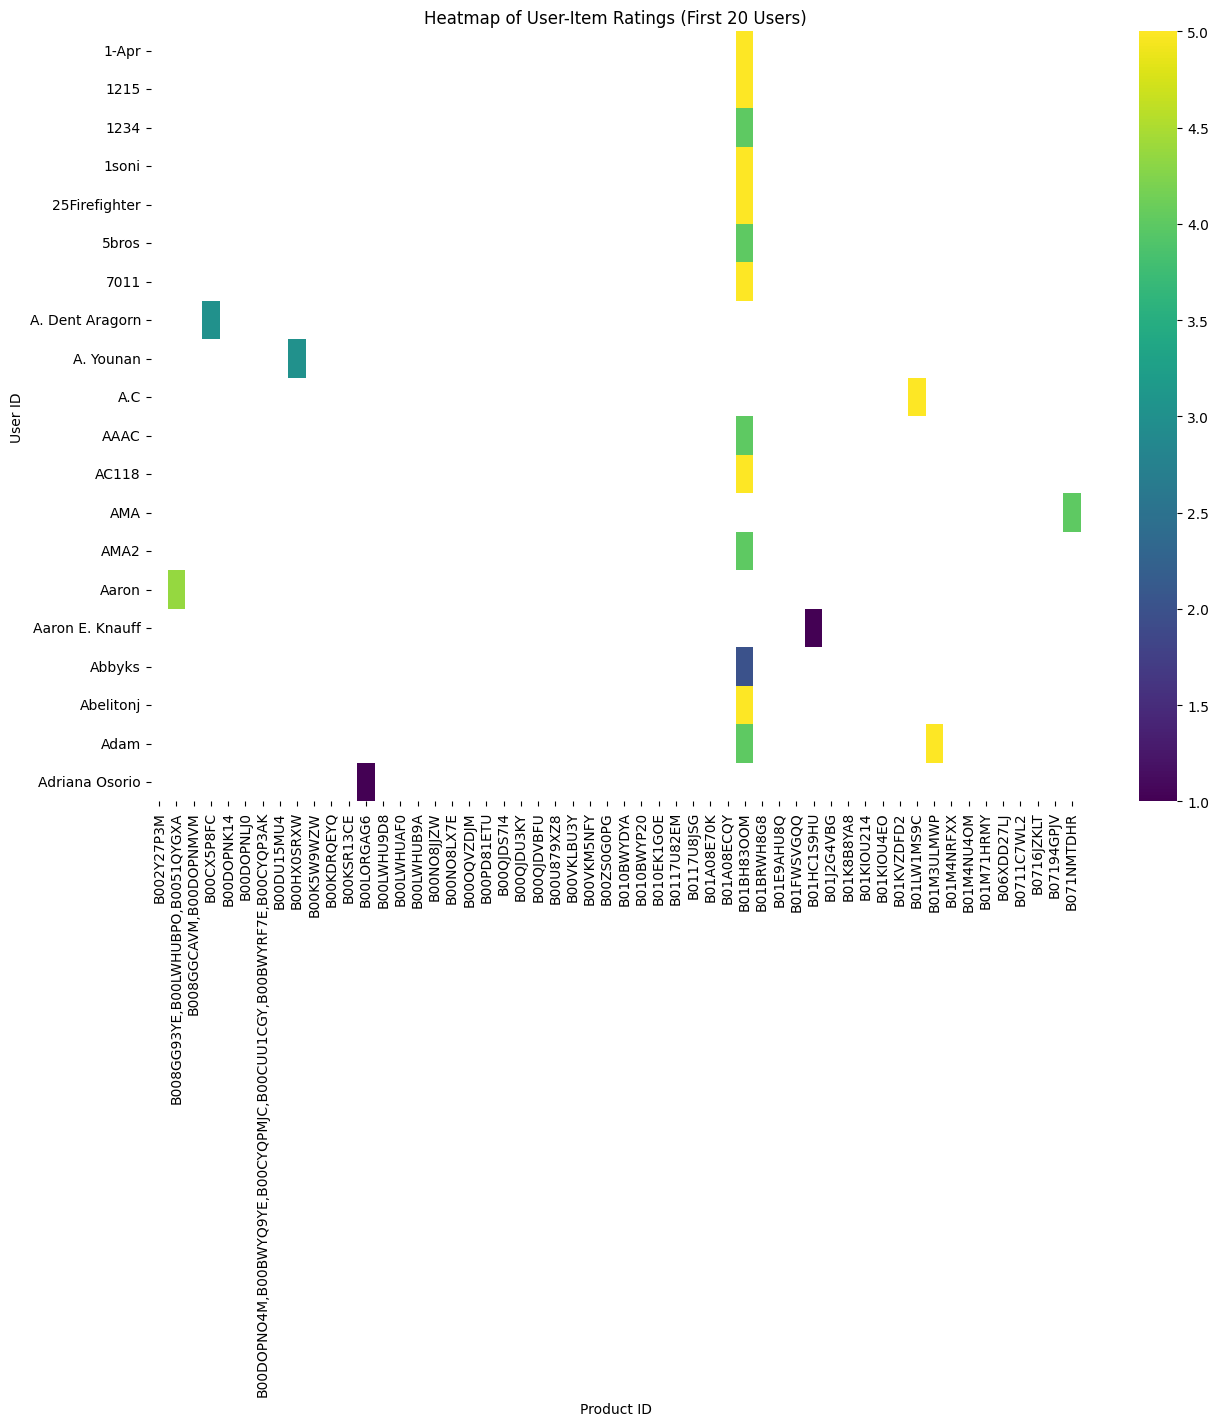

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the user-item matrix (a subset for better readability if it's too large)
plt.figure(figsize=(15, 10))
sns.heatmap(user_item_matrix.head(20), cmap='viridis', annot=False, fmt=".1f")
plt.title('Heatmap of User-Item Ratings (First 20 Users)')
plt.xlabel('Product ID')
plt.ylabel('User ID')
plt.show()


This heatmap visualizes the ratings given by users to different products. Each row represents a user, and each column represents a product. The color intensity indicates the rating value. For very large datasets, only a subset of users is shown for readability. Lighter colors indicate higher ratings, and darker colors indicate lower ratings. This helps in understanding how different users rate different products and identifying potential product correlation based on user ratings.

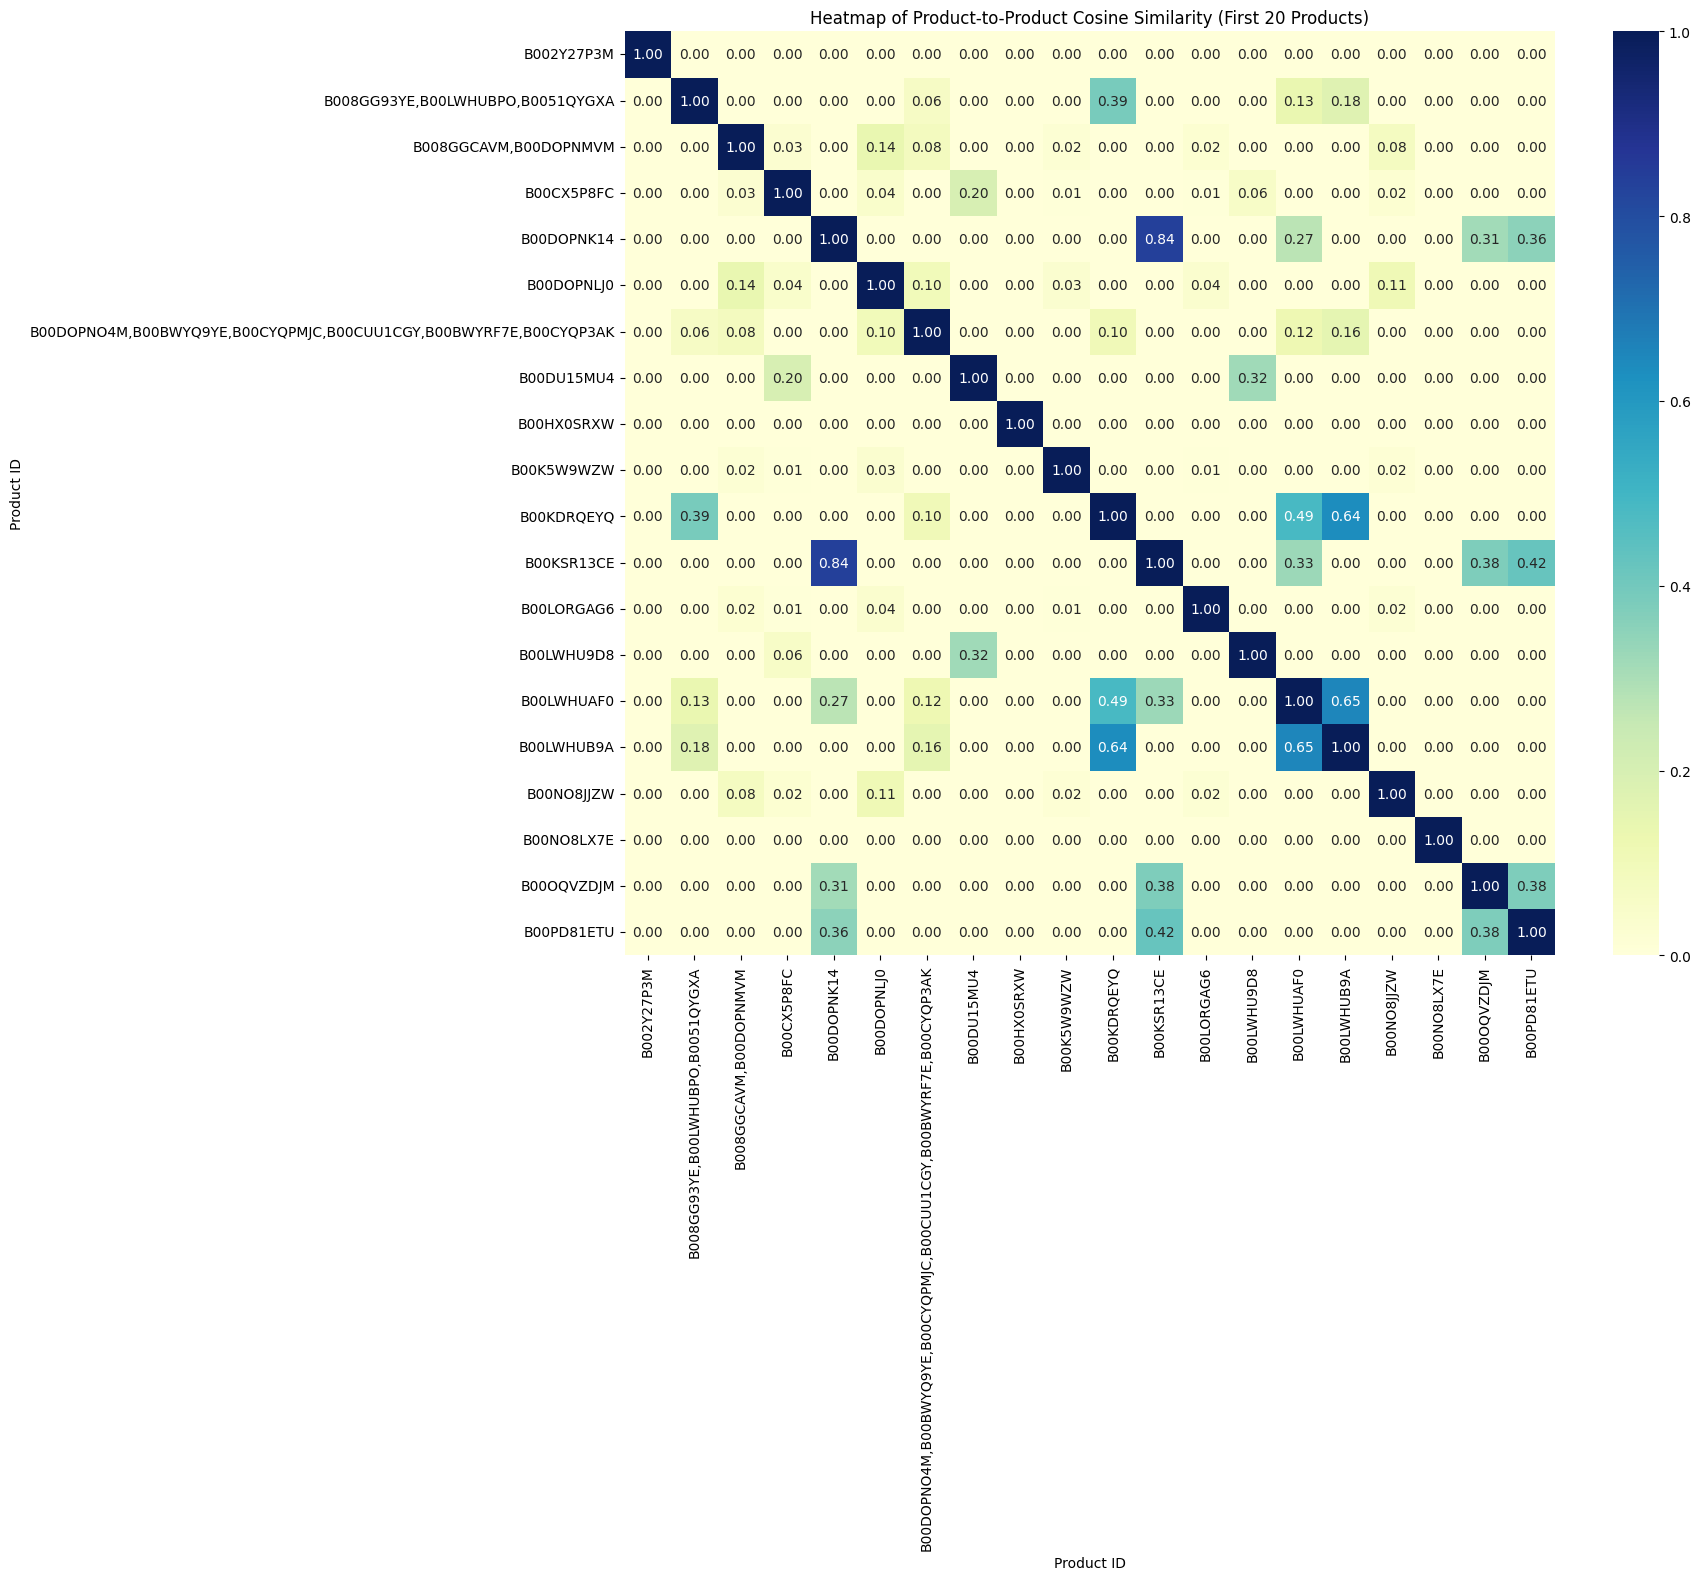

In [ ]:
# Calculate product-to-product correlation using cosine similarity
product_similarity_matrix = cosine_similarity(user_item_matrix.fillna(0).T)
product_similarity_df = pd.DataFrame(product_similarity_matrix, index=user_item_matrix.columns, columns=user_item_matrix.columns)

# Visualize product correlation (a subset for better readability)
plt.figure(figsize=(15, 12))
sns.heatmap(product_similarity_df.head(20).iloc[:, :20], cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('Heatmap of Product-to-Product Cosine Similarity (First 20 Products)')
plt.xlabel('Product ID')
plt.ylabel('Product ID')
plt.show()


This heatmap shows the cosine similarity between products. A value close to 1 indicates that products are rated similarly by users, suggesting a strong correlation. A value close to 0 suggests little to no correlation. This can help identify products that are often liked or disliked together.

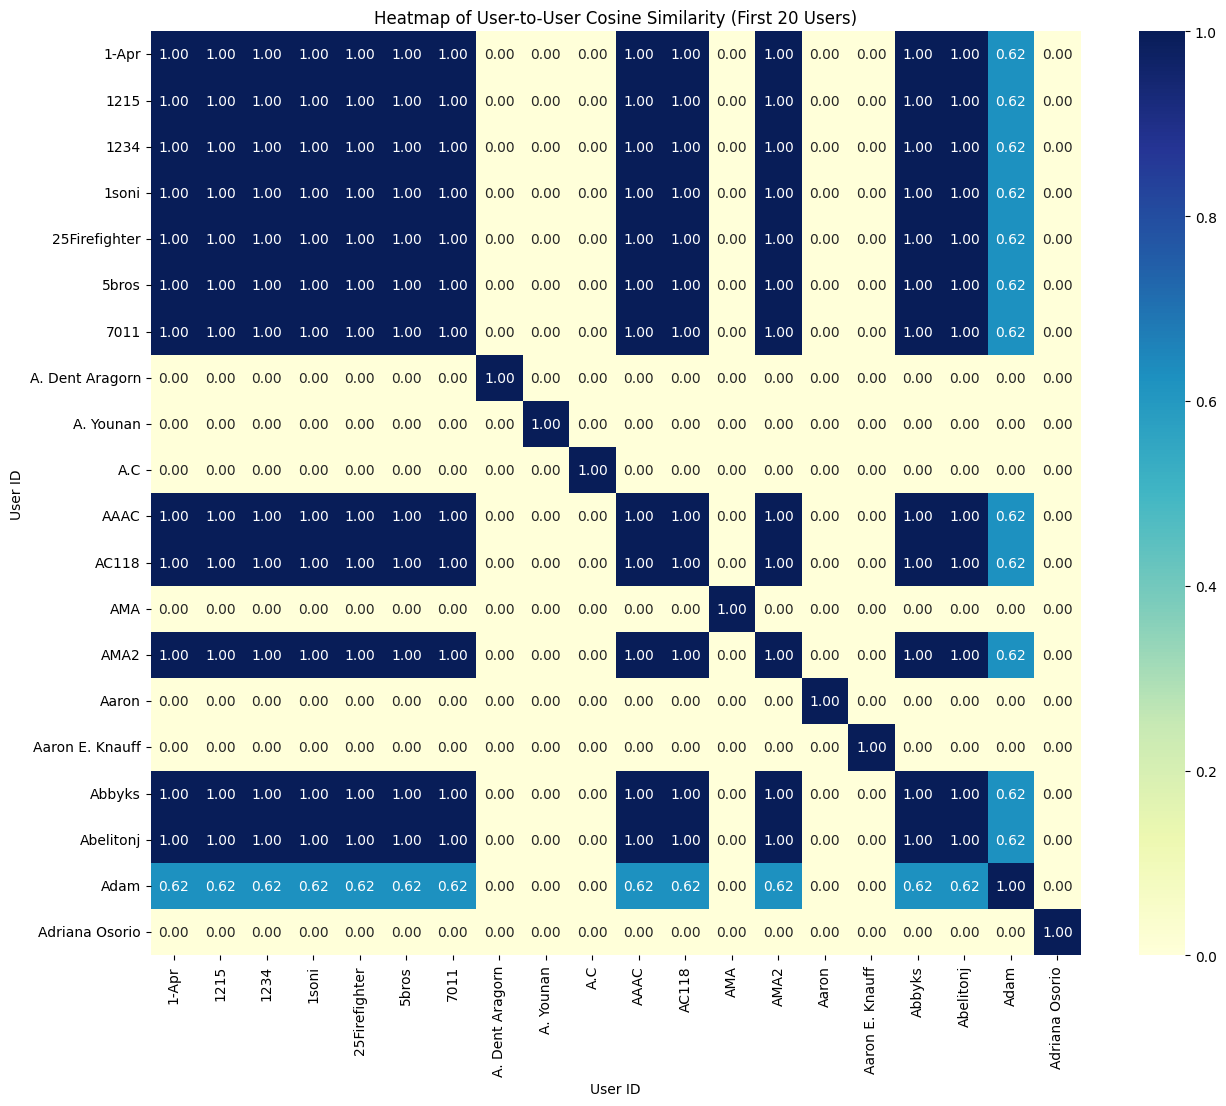

In [ ]:
# Calculate user-to-user correlation using cosine similarity
user_similarity_matrix = cosine_similarity(user_item_matrix.fillna(0))
user_similarity_df = pd.DataFrame(user_similarity_matrix, index=user_item_matrix.index, columns=user_item_matrix.index)

# Visualize user correlation (a subset for better readability)
plt.figure(figsize=(15, 12))
sns.heatmap(user_similarity_df.head(20).iloc[:, :20], cmap='YlGnBu', annot=True, fmt=".2f")
plt.title('Heatmap of User-to-User Cosine Similarity (First 20 Users)')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.show()


In [ ]:
def get_item_based_recommendations(product_id, product_similarity_df, product_name_map, top_n=5):
    if product_id not in product_similarity_df.columns:
        print(f"Product ID '{product_id}' not found.")
        return []

    # Get the similarity scores for the given product
    similar_products = product_similarity_df[product_id].sort_values(ascending=False)

    # Exclude the product itself and get the top N similar products
    recommendations = similar_products.drop(product_id).head(top_n)

    # Get names for recommended products
    recommended_product_ids = recommendations.index.tolist()
    recommended_products_with_names = []
    for pid in recommended_product_ids:
        # Check if pid exists in the map, otherwise use the ID itself
        product_name = product_name_map.get(pid, pid)
        recommended_products_with_names.append((pid, product_name))

    return recommended_products_with_names


The `get_item_based_recommendations` function takes a `product_id` and the `product_similarity_df` to find the most similar products. It sorts products by their similarity scores and returns the `top_n` recommendations, excluding the input product itself. This allows us to recommend items that are frequently rated similarly by users.

In [ ]:
# Get a sample product ID to test the recommendation system
sample_product_id = user_item_matrix.columns[0] # Using the first product in the matrix as an example
print(f"Sample Product ID for recommendations: {sample_product_id}")
# Get the name of the sample product
sample_product_name = product_name_map.get(sample_product_id, "Unknown Product")
print(f"Sample Product Name: {sample_product_name}")

# Get recommendations for the sample product
item_based_recommendations = get_item_based_recommendations(sample_product_id, product_similarity_df, product_name_map, top_n=10)

print(f"\nTop 10 Item-Based Recommendations for '{sample_product_id}' ({sample_product_name}):")
if item_based_recommendations:
    for pid, name in item_based_recommendations:
        print(f"- ID: {pid}, Name: {name}")
else:
    print("No recommendations found.")


Sample Product ID for recommendations: B002Y27P3M

Top 10 Item-Based Recommendations for 'B002Y27P3M':
B008GG93YE,B00LWHUBPO,B0051QYGXA
B008GGCAVM,B00DOPNMVM
B00CX5P8FC
B00DOPNK14
B00DOPNLJ0
B00DOPNO4M,B00BWYQ9YE,B00CYQPMJC,B00CUU1CGY,B00BWYRF7E,B00CYQP3AK
B00DU15MU4
B00HX0SRXW
B00K5W9WZW
B00KDRQEYQ


This code block demonstrates how to use the `get_item_based_recommendations` function. It selects a sample product (the first one from our `user_item_matrix`) and then prints the top 10 recommended products based on item-based collaborative filtering. These are products that users tend to rate similarly to our sample product.